# Survival Analysis — Asthma Biological Treatment
## Notebook 1: Preprocessing

This notebook prepares the dataset for three survival analyses:
- **Analysis 1**: Time to first biological treatment
- **Analysis 2**: Time to severe exacerbation after biological treatment start
- **Analysis 3**: Time to biological treatment failure after biological treatment start

**Steps:**
1. Load raw data and select relevant variables
2. Data quality filter (sparse records → censored)
3. Binary encoding of SI/NO variables
4. Categorical encoding
5. Time variables (T0, event, duration)
6. Missing value imputation
7. Export clean dataset

## 1. Imports and configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH   = Path('./data/data.csv')
OUTPUT_PATH = Path('./data/data_clean.csv')

# ── Parameters ─────────────────────────────────────────────────────────────
UMBRAL_NULOS = 0.80   # Records with >80% missing basal variables → censored

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Load raw data

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep=",", low_memory=False)
df_raw = df_raw.drop(columns=['NHC', 'Investigador', 'FechaNacimiento'])
print(f'Raw shape: {df_raw.shape}')
print(f'Columns: {df_raw.shape[1]}')
df_raw.head(3)

Raw shape: (1191, 115)
Columns: 115


,Id,Centro,Identificador,F_Visita_UnidadAsma,Edad,Genero,Peso,Talla,IMC,Tabaco,PaquetesAnho,FenotipoT2,Identificador.1,EdadInicioAsma,Obesidad,RGE,AnsiosoDepresivo,PatologiaTiroidea,SAOS,Bronquiectasias,EPOC,AspergilosisBroncopulmonar,Osteoporosis,Diabetes,PatologiaRinosinusal,TipoPatoRinosinusal,DermatitisAtopica,IntoleranciaAines,NumeroDeExacerbacionesQueHanRequeridoHospitalizaci,NExacerbacionesIngreso,NExacerbacionesCSS,PBDMas12,PeakFlowMas20,FeNOMas40ppb,Metacolina,RxToracica,TACToracico,TACSenosParanasales,PrickTest,EspecificarAlergenos,LABACI,DosisLABACI,LAMA,Antileucotrienos,Antihistaminicos,Macrolidos,AnticuerposMonoclonales,VacunaGripe,VacunaCovid,VacunaNeumococo,Vacuna_VRS,CorticoidesSistemicos,DosisCorticoidesOrales,OtrosTtoBasales,EspecificarOtrosTto,VAprox_3M,VAprox_6M,VAprox_12M,VAprox_24M,PrimerBiologico_bio,F_PrimerBiologico_bio,FechaRetirada_bio,MotivoRetirada_bio,EspecificarMotivo_bio,MotivoFracaso_bio,TipoEfectos_bio,SegundoBiologico_bio2,F_SegundoBiologico_bio2,FechaRetirada_bio2,MotivoRetirada_bio2,EspecificarMotivo_bio2,MotivoFracaso_bio2,TipoEfectos_bio2,ObjetivoTerapeutico,Identificador.2,ID_Visitas,IDVisita,F_Visita,1erBio,1erBio_Activo,1erBio_Tiempo,2doBio,2doBio_Activo,2doBio_Tiempo,ExacerbacionesGraves,ExacerGraves_con_ingreso,IngresosHosp,Sumatorio_N_exacerbaciones_graves_de_la_visita_3_m,FVCPorc,FVCValor,FEV1Porc,FEV1Valor,FEV1FVC,Reversible,IgETotal,Alfa_1_antitripsina,Ig_E_especifica_tipo,IGEEspecifica_Decimal,FEno,EosinofilosSerTot12m,VisitaxExacerbacion,TipoVisita,ModifTtoBasal,TratamientoHabitual,CorticoidesSistemicos.1,DosisAcumulada,CumplimentacionTto,LAMAs,OCS,ARLT,DosisICSLABA,MantieneAnticuerpoMonoclonal,FEOS,ACT_Valor,SNOT22
0,1,1166,1001,2024-04-09,65.00,Mujer,76.00,159.00,30.06,Nunca,NaN,F. Eosinofílico T2,1001,Tardio,No,Si,No,No,No,Si,No,No,No,No,Si,Sinusitis,No,Si,0.00,0.00,0.00,Si,NaN,No,No,Si,Si,No,Negativo,IgE D. Pteronyssinus 62.8 KUA/L,Si,Alta,No,No,No,No,Reslizumab,Si,Si,Si,No,Si,Mayor a 10 mg,No,NaN,2024-07-09,2024-10-09,2025-04-09,2026-04-09,Benralizumab,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1001.00,1001 - V0 - Basal al inicio del biológico,1.00,2024-03-25,Benralizumab,Activo,NaN,No recibe,Activo,NaN,0.00,0.00,0.00,NaN,111.00,3180.00,101.00,2270.00,0.71,No,NaN,NaN,NaN,NaN,21.00,0.00,No,NaN,No,NaN,No,NaN,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00
1,1,1166,1001,2024-04-09,65.00,Mujer,76.00,159.00,30.06,Nunca,NaN,F. Eosinofílico T2,1001,Tardio,No,Si,No,No,No,Si,No,No,No,No,Si,Sinusitis,No,Si,0.00,0.00,0.00,Si,NaN,No,No,Si,Si,No,Negativo,IgE D. Pteronyssinus 62.8 KUA/L,Si,Alta,No,No,No,No,Reslizumab,Si,Si,Si,No,Si,Mayor a 10 mg,No,NaN,2024-07-09,2024-10-09,2025-04-09,2026-04-09,Benralizumab,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1001.00,1001 - V1,2.00,2024-07-31,Benralizumab,Activo,NaN,No recibe,Activo,NaN,0.00,0.00,0.00,NaN,108.00,3090.00,93.00,2070.00,0.67,No,NaN,NaN,NaN,NaN,49.00,0.00,No,NaN,No,NaN,No,NaN,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1166,1001,2024-04-09,65.00,Mujer,76.00,159.00,30.06,Nunca,NaN,F. Eosinofílico T2,1001,Tardio,No,Si,No,No,No,Si,No,No,No,No,Si,Sinusitis,No,Si,0.00,0.00,0.00,Si,NaN,No,No,Si,Si,No,Negativo,IgE D. Pteronyssinus 62.8 KUA/L,Si,Alta,No,No,No,No,Reslizumab,Si,Si,Si,No,Si,Mayor a 10 mg,No,NaN,2024-07-09,2024-10-09,2025-04-09,2026-04-09,Benralizumab,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1001.00,1001 - V2,3.00,NaN,Benralizumab,Activo,NaN,No recibe,Activo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_raw = df_raw.rename(columns={"CorticoidesSistemicos.1": "CorticoidesSistemicos_visita"})
df_raw = df_raw.rename(columns={"LAMAs": "LAMAs_visita"})
df_raw = df_raw.rename(columns={"DosisICSLABA": "DosisICSLABA_visita"})

## 3. Variable selection

Manual selection of clinically relevant variables. All other columns are discarded as noise.

In [4]:
# ── Identifiers and dates ──────────────────────────────────────────────────
COLS_ID = [
    'Identificador',
    'F_Visita_UnidadAsma',    # T0: first visit to asthma unit
    'F_Visita',               # Last follow-up visit (censoring date)
]

# ── Basal clinical variables ───────────────────────────────────────────────
COLS_BASALES = [
    # Demographics
    'Edad',
    'Genero',
    'IMC',
    'Tabaco',
    'PaquetesAnho',
    # Asthma phenotype
    'FenotipoT2',
    'EdadInicioAsma',
    # Comorbidities
    'Obesidad',
    'RGE',
    'AnsiosoDepresivo',
    'PatologiaTiroidea',
    'SAOS',
    'Bronquiectasias',
    'EPOC',
    'AspergilosisBroncopulmonar',
    'Osteoporosis',
    'Diabetes',
    'PatologiaRinosinusal',
    'TipoPatoRinosinusal',
    'DermatitisAtopica',
    'IntoleranciaAines',
    # Diagnostic tests
    'PrickTest',
    'RxToracica',
    'TACToracico',
    'TACSenosParanasales',
    'VacunaGripe',
    'VacunaCovid',
    'VacunaNeumococo',
    'Vacuna_VRS',
    # Basal treatment
    'LABACI',
    'DosisLABACI',
    'LAMA',
    'Antileucotrienos',
    'Antihistaminicos',
    'Macrolidos',
    'CorticoidesSistemicos',
    'DosisCorticoidesOrales',
    'AnticuerposMonoclonales',  # null = naive, value = prior biological
]

# ── Pulmonary function and biomarkers ──────────────────────────────────────
COLS_FUNCION = [
    'FEV1Porc',
    'FEV1FVC',
    'FVCPorc',
    'IgETotal',
    'FEno',
    'EosinofilosSerTot12m',
    'Alfa_1_antitripsina',
]

# ── Treatment variables ────────────────────────────────────────────────────
COLS_TRATAMIENTO = [
    'PrimerBiologico_bio',
    'F_PrimerBiologico_bio',
    'FechaRetirada_bio',
    'MotivoRetirada_bio',
    'SegundoBiologico_bio2',
    'F_SegundoBiologico_bio2',
    'FechaRetirada_bio2',
]

# ── Visit variables ────────────────────────────────────────────────────────
COLS_VISITAS = [
    'ExacerbacionesGraves',
    'ExacerGraves_con_ingreso',
    'VisitaxExacerbacion',
    'TipoVisita',
    'CorticoidesSistemicos_visita',
    'DosisAcumulada',
    'ACT_Valor',
    'CumplimentacionTto',
    'ModifTtoBasal',
    'TratamientoHabitual',
    'LAMAs_visita',
    'DosisICSLABA_visita',
    'MantieneAnticuerpoMonoclonal',
    'SNOT22',
    
]

ALL_COLS = COLS_ID + COLS_BASALES + COLS_FUNCION + COLS_TRATAMIENTO + COLS_VISITAS

# Select and verify
missing_in_raw = [c for c in ALL_COLS if c not in df_raw.columns]
if missing_in_raw:
    print(f'WARNING — columns not found in raw data: {missing_in_raw}')

df = df_raw[[c for c in ALL_COLS if c in df_raw.columns]].copy()
print(f'Selected shape: {df.shape}')
df.head(3)

Selected shape: (1191, 69)


,Identificador,F_Visita_UnidadAsma,F_Visita,Edad,Genero,IMC,Tabaco,PaquetesAnho,FenotipoT2,EdadInicioAsma,Obesidad,RGE,AnsiosoDepresivo,PatologiaTiroidea,SAOS,Bronquiectasias,EPOC,AspergilosisBroncopulmonar,Osteoporosis,Diabetes,PatologiaRinosinusal,TipoPatoRinosinusal,DermatitisAtopica,IntoleranciaAines,PrickTest,RxToracica,TACToracico,TACSenosParanasales,VacunaGripe,VacunaCovid,VacunaNeumococo,Vacuna_VRS,LABACI,DosisLABACI,LAMA,Antileucotrienos,Antihistaminicos,Macrolidos,CorticoidesSistemicos,DosisCorticoidesOrales,AnticuerposMonoclonales,FEV1Porc,FEV1FVC,FVCPorc,IgETotal,FEno,EosinofilosSerTot12m,Alfa_1_antitripsina,PrimerBiologico_bio,F_PrimerBiologico_bio,FechaRetirada_bio,MotivoRetirada_bio,SegundoBiologico_bio2,F_SegundoBiologico_bio2,FechaRetirada_bio2,ExacerbacionesGraves,ExacerGraves_con_ingreso,VisitaxExacerbacion,TipoVisita,CorticoidesSistemicos_visita,DosisAcumulada,ACT_Valor,CumplimentacionTto,ModifTtoBasal,TratamientoHabitual,LAMAs_visita,DosisICSLABA_visita,MantieneAnticuerpoMonoclonal,SNOT22
0,1001,2024-04-09,2024-03-25,65.00,Mujer,30.06,Nunca,NaN,F. Eosinofílico T2,Tardio,No,Si,No,No,No,Si,No,No,No,No,Si,Sinusitis,No,Si,Negativo,Si,Si,No,Si,Si,Si,No,Si,Alta,No,No,No,No,Si,Mayor a 10 mg,Reslizumab,101.00,0.71,111.00,NaN,21.00,0.00,NaN,Benralizumab,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,No,NaN,No,NaN,NaN,100.00,No,NaN,NaN,NaN,NaN,0.00
1,1001,2024-04-09,2024-07-31,65.00,Mujer,30.06,Nunca,NaN,F. Eosinofílico T2,Tardio,No,Si,No,No,No,Si,No,No,No,No,Si,Sinusitis,No,Si,Negativo,Si,Si,No,Si,Si,Si,No,Si,Alta,No,No,No,No,Si,Mayor a 10 mg,Reslizumab,93.00,0.67,108.00,NaN,49.00,0.00,NaN,Benralizumab,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,No,NaN,No,NaN,NaN,100.00,No,NaN,NaN,NaN,NaN,NaN
2,1001,2024-04-09,NaN,65.00,Mujer,30.06,Nunca,NaN,F. Eosinofílico T2,Tardio,No,Si,No,No,No,Si,No,No,No,No,Si,Sinusitis,No,Si,Negativo,Si,Si,No,Si,Si,Si,No,Si,Alta,No,No,No,No,Si,Mayor a 10 mg,Reslizumab,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Benralizumab,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Parse dates

In [5]:
DATE_COLS = [
    'F_Visita_UnidadAsma',
    'F_Visita',
    'F_PrimerBiologico_bio',
    'FechaRetirada_bio',
    'F_SegundoBiologico_bio2',
    'FechaRetirada_bio2',
]

for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print('Date ranges:')
for col in DATE_COLS:
    if col in df.columns:
        print(f'  {col}: {df[col].min().date()} → {df[col].max().date()} '
              f'(null: {df[col].isna().sum()})')

Date ranges:
  F_Visita_UnidadAsma: 2000-07-15 → 2025-10-20 (null: 112)
  F_Visita: 2015-02-06 → 2026-03-03 (null: 167)
  F_PrimerBiologico_bio: 2013-03-18 → 2026-01-13 (null: 116)
  FechaRetirada_bio: 2018-02-05 → 2026-01-22 (null: 987)
  F_SegundoBiologico_bio2: 2017-12-22 → 2026-01-22 (null: 1030)
  FechaRetirada_bio2: 2021-05-05 → 2025-07-12 (null: 1131)


## 5. Data quality filter

Records with >80% missing basal variables are considered uninformative.
If `AnticuerposMonoclonales` is null **and** the record is sparse → censored (not naive).

Records above 80% missing threshold: 82 / 1191


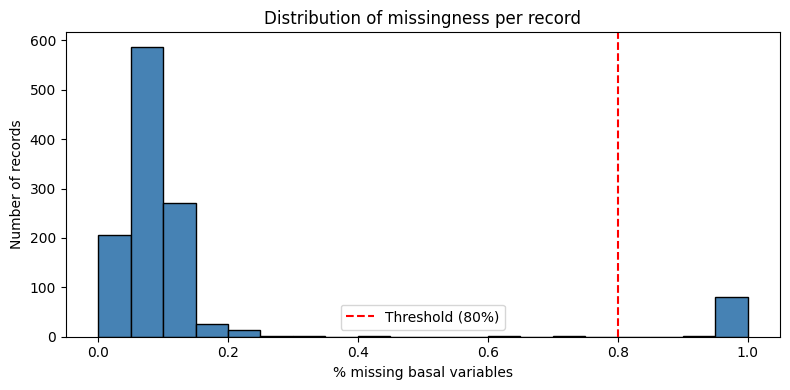

In [6]:
# % missing across basal variables per record
df['pct_nulos_basales'] = df[COLS_BASALES].isnull().mean(axis=1)

# Flag sparse records
df['registro_valido'] = df['pct_nulos_basales'] <= UMBRAL_NULOS

print(f'Records above {UMBRAL_NULOS:.0%} missing threshold: '
      f'{(~df["registro_valido"]).sum()} / {len(df)}')

# Distribution of missingness
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['pct_nulos_basales'], bins=20, edgecolor='black', color='steelblue')
ax.axvline(UMBRAL_NULOS, color='red', linestyle='--', label=f'Threshold ({UMBRAL_NULOS:.0%})')
ax.set_xlabel('% missing basal variables')
ax.set_ylabel('Number of records')
ax.set_title('Distribution of missingness per record')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Binary encoding of SI/NO variables

In [7]:
COLS_SINO = [
    'Obesidad', 'RGE', 'AnsiosoDepresivo', 'PatologiaTiroidea',
    'SAOS', 'Bronquiectasias', 'EPOC', 'Osteoporosis', 'Diabetes',
    'PatologiaRinosinusal', 'DermatitisAtopica', 'IntoleranciaAines',
    'LABACI', 'LAMA', 'Antileucotrienos',
    'Macrolidos', 'CorticoidesSistemicos', 'CorticoidesSistemicos_visita',
    'ModifTtoBasal', 'AspergilosisBroncopulmonar',
    'RxToracica', 'TACToracico', 'TACSenosParanasales', 'Antihistaminicos', 'VacunaGripe',
    'VacunaCovid', 'VacunaNeumococo', 'Vacuna_VRS', 'LAMAs_visita', 'MantieneAnticuerpoMonoclonal',
    'VisitaxExacerbacion',
]

for col in COLS_SINO:
    if col in df.columns:
        df[col] = df[col].map({'SI': 1, 'NO': 0, 'Si': 1, 'No': 0,
                               'SÍ': 1, 'Sí': 1, 'sí': 1, 'si': 1,
                               'no': 0})

print('Binary encoding done.')
df[COLS_SINO].head(3)

Binary encoding done.


,Obesidad,RGE,AnsiosoDepresivo,PatologiaTiroidea,SAOS,Bronquiectasias,EPOC,Osteoporosis,Diabetes,PatologiaRinosinusal,DermatitisAtopica,IntoleranciaAines,LABACI,LAMA,Antileucotrienos,Macrolidos,CorticoidesSistemicos,CorticoidesSistemicos_visita,ModifTtoBasal,AspergilosisBroncopulmonar,RxToracica,TACToracico,TACSenosParanasales,Antihistaminicos,VacunaGripe,VacunaCovid,VacunaNeumococo,Vacuna_VRS,LAMAs_visita,MantieneAnticuerpoMonoclonal,VisitaxExacerbacion
0,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,NaN,NaN,0.00
1,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,NaN,NaN,0.00
2,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,NaN,NaN,0.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,NaN,NaN,NaN


## 7. Categorical encoding

In [8]:
# ── TipoPatoRinosinusal ─────────────────────────────────────────────────────────────
tipopat_map = {'Polipos': 0, 'Pólipos': 0, 'polipos': 0,
               'Rinitis': 1, 'rinitis': 1,
               'Rinosinusitis': 2, 'rinosinusitis': 2,
               'Sinusitis': 3, 'sinusitis': 3,
               'Anosmia': 4, 'anosmia': 4
              }
df['TipoPatoRinosinusal'] = df['TipoPatoRinosinusal'].map(tipopat_map)


# ── Genero ─────────────────────────────────────────────────────────────────
df['Genero'] = df['Genero'].map({'Varon': 0, 'Mujer': 1,
                                  'varon': 0, 'mujer': 1,
                                  'V': 0, 'M': 1})

# ── Tabaco ─────────────────────────────────────────────────────────────────
tabaco_map = {'nunca': 0, 'Nunca': 0, 'exfumador': 1, 'ExFumador': 1,
              'activo': 2, 'Activo': 2, 'fumador activo': 2}
df['Tabaco'] = df['Tabaco'].map(tabaco_map)

# ── FenotipoT2 ─────────────────────────────────────────────────────────────
fenotipo_map = {'Fenotipono T2': 0, 'Fenotipo No T2': 0, 'Fenotipo no t2': 0,
                'F. Eosinofílico T2': 1, 'f. eosinofílico T2': 1, 'F. Eosinofilico T2': 1,
                'F. Alérgico T2': 2, 'f. alérgico T2': 2, 'F. Alergico T2': 2}
df['FenotipoT2'] = df['FenotipoT2'].map(fenotipo_map)

# ── EdadInicioAsma ─────────────────────────────────────────────────────────
df['EdadInicioAsma'] = df['EdadInicioAsma'].map({'temprano': 0, 'Temprano': 0,
                                                   'tardío': 1, 'Tardío': 1,
                                                   'tardio': 1, 'Tardio': 1})

# ── DosisLABACI ────────────────────────────────────────────────────────────
dosis_map = {'baja': 0, 'Baja': 0, 'media': 1, 'Media': 1, 'alta': 2, 'Alta': 2}
df['DosisLABACI'] = df['DosisLABACI'].map(dosis_map)

# ── DosisICSLABA_visita ────────────────────────────────────────────────────────────
dosis_map = {'baja': 0, 'Baja': 0, 'media': 1, 'Media': 1, 'alta': 2, 'Alta': 2}
df['DosisICSLABA_visita'] = df['DosisICSLABA_visita'].map(dosis_map)

# ── TratamientoHabitual ────────────────────────────────────────────────────────────
dosis_map = {'Aumento dosis': 0, 'aumento dosis': 0, 'Descenso dosis': 1, 'descenso dosis': 1, 'Mantenimiento dosis': 2, 'mantenimiento dosis': 2}
df['TratamientoHabitual'] = df['TratamientoHabitual'].map(dosis_map)

# ── DosisCorticoidesOrales ─────────────────────────────────────────────────
df['DosisCorticoidesOrales'] = df['DosisCorticoidesOrales'].map(
    {'menor a 5 mg': 0, 'Menor a 5 mg': 0,
     'entre 5 y 10 mg': 1, 'Entre 5 y 10 mg': 1,
     'mayor a 10 mg': 2, 'Mayor a 10 mg': 2}
)

# ── DosisAcumulada ─────────────────────────────────────────────────
df['DosisAcumulada'] = df['DosisAcumulada'].map(
    {'menor a 5 mg': 0, 'Menor a 5 mg': 0,
     'Entre 5 y 10 mg': 1, 'entre 5 y 10 mg': 1,
     'mayor a 10 mg': 2, 'Mayor a 10 mg': 2}
)


# ── TipoVisita ─────────────────────────────────────────────────
df['TipoVisita'] = df['TipoVisita'].map(
    {'Ingreso': 0, 'ingreso': 0,
     'MAP': 1, 'map': 1,
     'Urgencias': 2, 'urgencias': 2}
)


# ── PrickTest ──────────────────────────────────────────────────────────────
df['PrickTest'] = df['PrickTest'].map({'negativo': 0, 'Negativo': 0,
                                        'positivo': 1, 'Positivo': 1})


# ── AnticuerposMonoclonales ──────────────────────────────────────────────────────────────
df['AnticuerposMonoclonales'] = df['AnticuerposMonoclonales'].map({'Dupilumab': 0, 'dupilumab': 0,
                                                     'Omalizumab': 1, 'omalizumab': 1,
                                                     'Mepolizumab': 2, 'mepolizumab': 2,
                                                     'Benralizumab': 3, 'Benralizumab': 3,
                                                     'Reslizumab': 4, 'Reslizumab': 4,
                                                     'Tezepelumab':5, 'Tezepelumab': 5})

# null = not performed → keep as NaN

# ── AnticuerposMonoclonales — naive flag ───────────────────────────────────
# null + valid record = naive (0)
# null + sparse record = unknown, treated as censored downstream
# value = prior biological (1 = biological switch)
df['BiologicoSwitch'] = (
    df['AnticuerposMonoclonales'].notna() & df['registro_valido']
).astype(int)

print('Categorical encoding done.')
df[['Genero', 'Tabaco', 'TipoPatoRinosinusal', 'FenotipoT2', 'EdadInicioAsma',
    'DosisLABACI', 'PrickTest', 'BiologicoSwitch', 'TratamientoHabitual', 'DosisAcumulada']].value_counts().head(10)

Categorical encoding done.


Genero  Tabaco  TipoPatoRinosinusal  FenotipoT2  EdadInicioAsma  DosisLABACI  PrickTest  BiologicoSwitch  TratamientoHabitual  DosisAcumulada
0.00    0.00    1.00                 2.00        0.00            2.00         1.00       1                0.00                 1.00              1
1.00    0.00    0.00                 1.00        1.00            1.00         0.00       0                2.00                 1.00              1
        1.00    2.00                 1.00        0.00            2.00         1.00       1                0.00                 2.00              1
Name: count, dtype: int64

## 8. Survival time variables

Three event definitions, one per analysis.

In [9]:
# ── Analysis 1: Time to first biological ──────────────────────────────────
# Event:    received first biological (F_PrimerBiologico_bio not null)
# T0:       F_Visita_UnidadAsma
# Censored: no biological during follow-up OR sparse record
df['evento_bio'] = (
    df['F_PrimerBiologico_bio'].notna() & df['registro_valido']
).astype(int)

df['tiempo_bio'] = np.where(
    df['evento_bio'] == 1,
    (df['F_PrimerBiologico_bio'] - df['F_Visita_UnidadAsma']).dt.days,
    (df['F_Visita'] - df['F_Visita_UnidadAsma']).dt.days
)

# ── Analysis 2: Time to severe exacerbation ────────────────────────────────
# T0:       F_PrimerBiologico_bio (time on biological until first exacerbation)
# Event 1:  ExacerbacionesGraves  → severe exacerbation
# Event 2:  ExacerGraves_con_ingreso → hospitalisation due to asthma crisis
# Strategy: iterate over longitudinal visits per patient, find first visit
#           after T0 where the event variable > 0.

df['F_Visita'] = pd.to_datetime(df['F_Visita'], errors='coerce')
df['F_PrimerBiologico_bio'] = pd.to_datetime(df['F_PrimerBiologico_bio'], errors='coerce')

df_sorted = df.sort_values(['Identificador', 'F_Visita'])

records_exac = []
records_hosp = []

for pid, group in df_sorted.groupby('Identificador'):
    t0 = group['F_PrimerBiologico_bio'].iloc[0]
    last_visit = group['F_Visita'].max()

    if pd.isna(t0):
        # Never received biological — censored at last visit from T0=NaT → will be NaN
        records_exac.append({'Identificador': pid, 'evento_exac': 0, 'tiempo_exac': np.nan})
        records_hosp.append({'Identificador': pid, 'evento_hosp': 0, 'tiempo_hosp': np.nan})
        continue

    after_t0 = group[group['F_Visita'] > t0]

    # ── Severe exacerbation ────────────────────────────────────────────────
    exac_visits = after_t0[after_t0['ExacerbacionesGraves'].fillna(0) > 0]
    if len(exac_visits) > 0:
        first_exac = exac_visits['F_Visita'].min()
        records_exac.append({
            'Identificador': pid,
            'evento_exac': 1,
            'tiempo_exac': (first_exac - t0).days
        })
    else:
        records_exac.append({
            'Identificador': pid,
            'evento_exac': 0,
            'tiempo_exac': (last_visit - t0).days
        })

    # ── Hospitalisation due to asthma crisis ──────────────────────────────
    hosp_visits = after_t0[after_t0['ExacerGraves_con_ingreso'].fillna(0) > 0]
    if len(hosp_visits) > 0:
        first_hosp = hosp_visits['F_Visita'].min()
        records_hosp.append({
            'Identificador': pid,
            'evento_hosp': 1,
            'tiempo_hosp': (first_hosp - t0).days
        })
    else:
        records_hosp.append({
            'Identificador': pid,
            'evento_hosp': 0,
            'tiempo_hosp': (last_visit - t0).days
        })

df_exac = pd.DataFrame(records_exac).set_index('Identificador')
df_hosp = pd.DataFrame(records_hosp).set_index('Identificador')

# Merge back — one row per patient (index = Identificador after groupby.first())
# Drop existing columns if present (avoid conflicts on re-runs)
df.drop(columns=['evento_exac', 'tiempo_exac', 'evento_hosp', 'tiempo_hosp'],
        inplace=True, errors='ignore')

df = df.join(df_exac, on='Identificador', how='left')
df = df.join(df_hosp, on='Identificador', how='left')

# ── Analysis 3: Time to biological failure ────────────────────────────────
# Event:    FechaRetirada_bio not null (biological was withdrawn)
# T0:       F_PrimerBiologico_bio
# Censored: still on first biological at last visit
df['evento_fallo'] = df['FechaRetirada_bio'].notna().astype(int)

df['tiempo_fallo'] = np.where(
    df['evento_fallo'] == 1,
    (df['FechaRetirada_bio'] - df['F_PrimerBiologico_bio']).dt.days,
    (df['F_Visita'] - df['F_PrimerBiologico_bio']).dt.days
)

# ── Remove negative times (data inconsistencies) ──────────────────────────
for col in ['tiempo_bio', 'tiempo_exac', 'tiempo_hosp', 'tiempo_fallo']:
    if col in df.columns:
        n_neg = (df[col] < 0).sum()
        if n_neg > 0:
            print(f'WARNING — {n_neg} negative values in {col} → set to NaN')
            df.loc[df[col] < 0, col] = np.nan

# Note: summary below is computed on the full longitudinal dataframe.
# Final per-patient counts will be shown in section 10 after export.
print('\nEvent summary (longitudinal, pre-collapse):')
for ev, t in [('evento_bio',   'tiempo_bio'),
              ('evento_exac',  'tiempo_exac'),
              ('evento_hosp',  'tiempo_hosp'),
              ('evento_fallo', 'tiempo_fallo')]:
    if ev in df.columns:
        n_ev  = df[ev].sum()
        med_t = df.loc[df[ev] == 1, t].median()
        print(f'  {ev}: {n_ev} events | median time to event: {med_t:.0f} days')


WARNING — 31 negative values in tiempo_bio → set to NaN
WARNING — 39 negative values in tiempo_exac → set to NaN
WARNING — 39 negative values in tiempo_hosp → set to NaN
WARNING — 108 negative values in tiempo_fallo → set to NaN

Event summary (longitudinal, pre-collapse):
  evento_bio: 1027 events | median time to event: 225 days
  evento_exac: 447 events | median time to event: 193 days
  evento_hosp: 161 events | median time to event: 266 days
  evento_fallo: 204 events | median time to event: 442 days


## 9. Missing value imputation

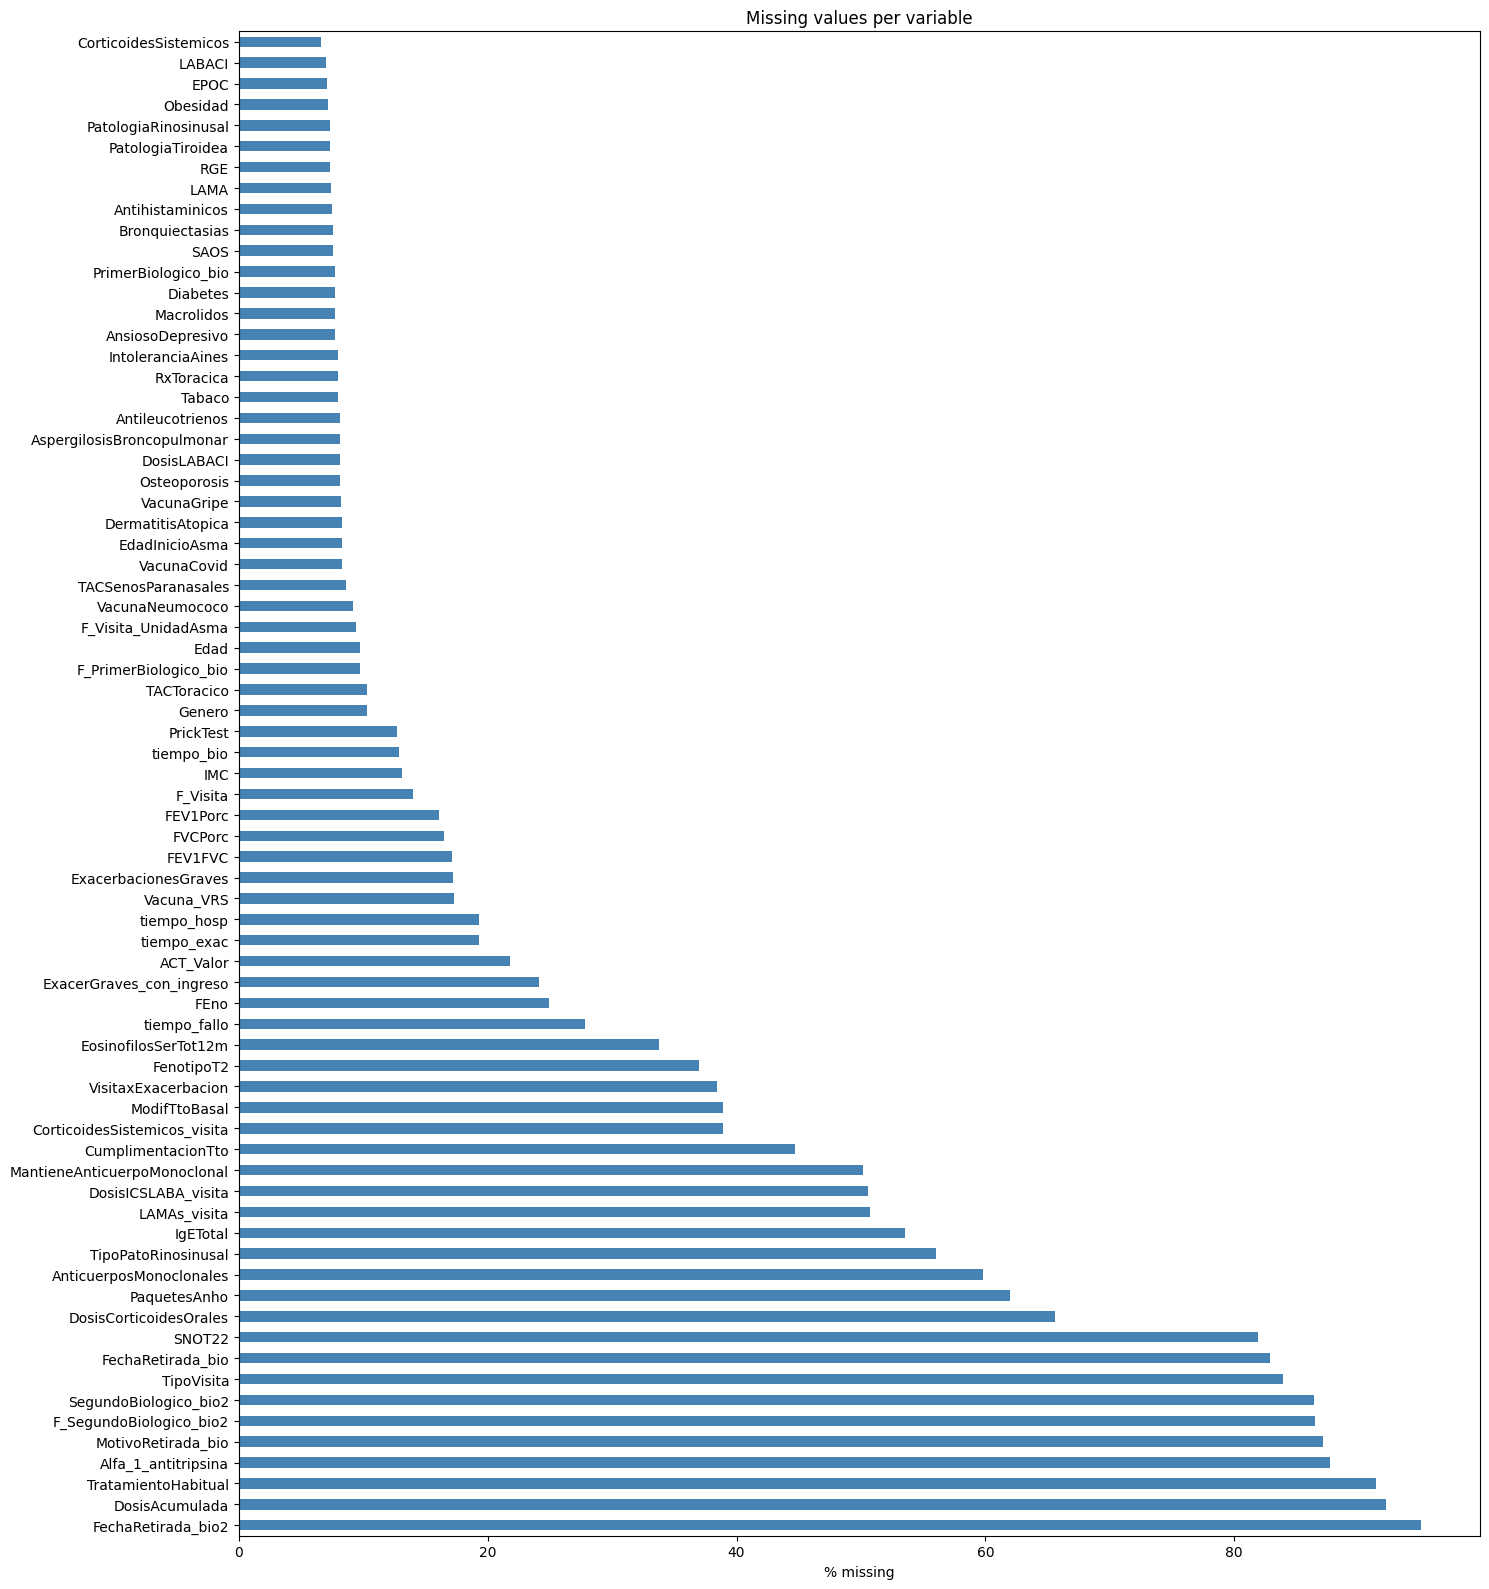

                       missing   pct
FechaRetirada_bio2        1131 95.00
DosisAcumulada            1098 92.20
TratamientoHabitual       1089 91.40
Alfa_1_antitripsina       1044 87.70
MotivoRetirada_bio        1037 87.10
...                        ...   ...
PatologiaRinosinusal        87  7.30
Obesidad                    86  7.20
EPOC                        84  7.10
LABACI                      83  7.00
CorticoidesSistemicos       79  6.60

[72 rows x 2 columns]


In [14]:
# Overview of missingness
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(15, 16))
missing_pct.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% missing')
ax.set_title('Missing values per variable')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'missing': missing, 'pct': missing_pct}))

In [15]:
# ── Continuous variables → median imputation ───────────────────────────────
COLS_CONTINUAS = [
    'Edad', 'IMC', 'PaquetesAnho',
    'FEV1Porc', 'FEV1FVC', 'FVCPorc',
    'IgETotal', 'FEno', 'EosinofilosSerTot12m',
    'ACT_Valor',
]

for col in COLS_CONTINUAS:
    if col in df.columns and df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# ── Binary/ordinal variables → mode imputation ────────────────────────────
COLS_CATEGORICAS = COLS_SINO + [
    'Genero', 'Tabaco', 'FenotipoT2', 'EdadInicioAsma',
    'DosisLABACI', 'DosisCorticoidesOrales', 'PrickTest',
]

for col in COLS_CATEGORICAS:
    if col in df.columns and df[col].isna().sum() > 0:
        moda = df[col].mode()
        if len(moda) == 0:
            print(f'WARNING — {col} is entirely null, skipping imputation')
            continue
        df[col] = df[col].fillna(moda[0])

print('Imputation done.')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

Imputation done.
Remaining nulls: 14858


## 10. Final dataset overview

In [16]:
# Final feature set for survival models
FEATURES = (
    ['Edad', 'Genero', 'IMC', 'Tabaco', 'PaquetesAnho', 'FenotipoT2',
     'EdadInicioAsma', 'BiologicoSwitch']
    + COLS_SINO
    + ['DosisLABACI', 'DosisCorticoidesOrales', 'PrickTest']
    + COLS_FUNCION
)

# Keep only valid records for Analysis 1
df_valid = df[df['registro_valido']].copy()

print(f'Final dataset (valid records): {df_valid.shape}')
print(f'\nEvent rates:')
print(f'  Time to biological:  {df_valid["evento_bio"].mean():.1%} events')
print(f'  Time to exacerbation: {df_valid["evento_exac"].mean():.1%} events')
print(f'  Time to failure:     {df_valid["evento_fallo"].mean():.1%} events')

df_valid.describe().T

Final dataset (valid records): (1109, 80)

Event rates:
  Time to biological:  92.6% events
  Time to exacerbation: 40.3% events
  Time to failure:     17.9% events


,count,mean,min,25%,50%,75%,max,std
Identificador,1109.00,10180.36,1001.00,2013.00,9005.00,18002.00,25019.00,7709.08
F_Visita_UnidadAsma,1079,2021-12-11 21:53:12.956441088,2000-07-15 00:00:00,2021-05-14 00:00:00,2023-08-18 00:00:00,2024-05-15 00:00:00,2025-10-20 00:00:00,NaN
F_Visita,1015,2024-10-08 03:17:12.118226432,2015-02-06 00:00:00,2024-06-04 00:00:00,2024-11-26 00:00:00,2025-04-23 00:00:00,2026-03-03 00:00:00,NaN
Edad,1109.00,55.91,18.00,47.00,57.00,67.00,86.00,14.62
Genero,1109.00,0.72,0.00,0.00,1.00,1.00,1.00,0.45
...,...,...,...,...,...,...,...,...
tiempo_exac,952.00,338.43,0.00,116.00,299.00,388.00,4308.00,392.91
evento_hosp,1109.00,0.15,0.00,0.00,0.00,0.00,1.00,0.35
tiempo_hosp,952.00,414.53,0.00,222.00,349.00,453.00,4489.00,426.66
evento_fallo,1109.00,0.18,0.00,0.00,0.00,0.00,1.00,0.38


## 11. Export clean dataset

In [17]:
# Keep only baseline visit per patient
df['F_Visita'] = pd.to_datetime(df['F_Visita'], errors='coerce')

df_valid = (
    df[df['registro_valido']]
      .sort_values('F_Visita')
      .groupby('Identificador')
      .first()
      .reset_index()
)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_valid.to_csv(OUTPUT_PATH, index=False)

print(f'Clean dataset saved to: {OUTPUT_PATH}')
print(f'Shape: {df_valid.shape}')
print(f'Columns: {list(df_valid.columns)}')

Clean dataset saved to: data/data_clean.csv
Shape: (395, 80)
Columns: ['Identificador', 'F_Visita_UnidadAsma', 'F_Visita', 'Edad', 'Genero', 'IMC', 'Tabaco', 'PaquetesAnho', 'FenotipoT2', 'EdadInicioAsma', 'Obesidad', 'RGE', 'AnsiosoDepresivo', 'PatologiaTiroidea', 'SAOS', 'Bronquiectasias', 'EPOC', 'AspergilosisBroncopulmonar', 'Osteoporosis', 'Diabetes', 'PatologiaRinosinusal', 'TipoPatoRinosinusal', 'DermatitisAtopica', 'IntoleranciaAines', 'PrickTest', 'RxToracica', 'TACToracico', 'TACSenosParanasales', 'VacunaGripe', 'VacunaCovid', 'VacunaNeumococo', 'Vacuna_VRS', 'LABACI', 'DosisLABACI', 'LAMA', 'Antileucotrienos', 'Antihistaminicos', 'Macrolidos', 'CorticoidesSistemicos', 'DosisCorticoidesOrales', 'AnticuerposMonoclonales', 'FEV1Porc', 'FEV1FVC', 'FVCPorc', 'IgETotal', 'FEno', 'EosinofilosSerTot12m', 'Alfa_1_antitripsina', 'PrimerBiologico_bio', 'F_PrimerBiologico_bio', 'FechaRetirada_bio', 'MotivoRetirada_bio', 'SegundoBiologico_bio2', 'F_SegundoBiologico_bio2', 'FechaRetirada_